### 1. Setup

In [1]:
import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision.utils import save_image
from pathlib import Path
from dataclasses import asdict
import sys
import os
import json
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

# Add utils and models to path
project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

from preprocessing import Preprocessing
from cvae_cnn import CVAE
from counterfactual_evaluation import (
    fid_metric_calculation,
    ssim_metric_calculation,
    save_cvae_change_heatmap_sweep,
    EvaluationResult,
    write_metrics_json,
)

### 2. Hyperparameters

In [2]:
img_channels = 1
img_size = 128
latent_dim = 64
num_classes = 2
metadata_dim = 2
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

verbose = True
method = 'standard'

lr=3e-4
epochs = 300
batch_size = 64
beta = 0.02

Using device: cuda


### 3. Load Dataset

In [ ]:
# preprocessing = Preprocessing(label="Pneumonia")

In [ ]:
# # Create CVAE-compatible dataset
# train_dataset, test_dataset, val_dataset = preprocessing.create_cvae_dataset(
#     img_size=(img_size, img_size),
#     verbose=verbose, 
#     method=method
# )

Creating CVAE dataset...
Loading images...
Pneumonia patient records:
Number of duplicated rows: 0
Removed 0 outliers based on Patient Age.
New shape of dataframe: (322, 11)
Age normalized using standardization. Mean: 41.30, Std: 18.33
Healthy patient records:
Number of duplicated rows: 0
Removed 8 outliers based on Patient Age.
New shape of dataframe: (60353, 11)
Age normalized using Min-Max scaling. Range: [1, 95] -> [0, 1]
Total unique patients: 24946

--- Split Statistics (Patient-Level) ---
Seed: 42 (for reproducibility)

TRAIN set:
  Patients: 17462
  Total images: 42452
  Pneumonia: 223 images
  Healthy: 42229 images
  Ratio: 70.0%

VAL set:
  Patients: 3741
  Total images: 8798
  Pneumonia: 49 images
  Healthy: 8749 images
  Ratio: 14.5%

TEST set:
  Patients: 3743
  Total images: 9425
  Pneumonia: 50 images
  Healthy: 9375 images
  Ratio: 15.5%
Loaded 42452 images.
Loaded 8798 images.
Loaded 9425 images.


In [ ]:
# DATA_CACHE_DIR = project_root / "data" / "processed"
# DATA_CACHE_DIR.mkdir(parents=True, exist_ok=True)

# torch.save(train_dataset, DATA_CACHE_DIR / "train_dataset.pt")
# torch.save(val_dataset,   DATA_CACHE_DIR / "val_dataset.pt")
# torch.save(test_dataset,  DATA_CACHE_DIR / "test_dataset.pt")

# print(f"Datasets salvos em {DATA_CACHE_DIR}")

Datasets salvos em E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\data\processed


In [2]:
# Load datasets from cache:
DATA_CACHE_DIR = project_root / "data" / "processed"
train_dataset = torch.load(DATA_CACHE_DIR / "train_dataset.pt", weights_only=False)
val_dataset   = torch.load(DATA_CACHE_DIR / "val_dataset.pt", weights_only=False)
test_dataset  = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

In [4]:
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

### 4. Model, Loss, Optimizer

In [17]:
def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    x_flat = x.view(x.size(0), -1)
    x_hat_flat = x_hat.view(x.size(0), -1)
    reconstruction_loss = 0.5 * F.mse_loss(x_hat_flat, x_flat, reduction='mean') \
                    + 0.5 * F.l1_loss(x_hat_flat, x_flat, reduction='mean')
    # Normalize KLD by the batch size so it is on the same scale as the reconstruction loss.
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    KLD = KLD / x_flat.size(0)
    return reconstruction_loss + beta * KLD, reconstruction_loss, KLD


In [45]:
model = CVAE(
    img_channels=img_channels,
    img_size=img_size,
    latent_dim=latent_dim,
    num_classes=num_classes,
    metadata_dim=metadata_dim  # age + gender
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=lr)

### 5. Training

In [46]:
def evaluate(model, evaluate_loader, device, epoch, beta=1.0, results_dir="../training-results/cvae/results"):
    model.eval()
    total_loss = 0
    total_rec_loss = 0
    total_kld = 0
    with torch.no_grad():
        for i, batch in enumerate(evaluate_loader):
            x, y, m = batch
            x = x.to(device)
            y = y.to(device)
            m = m.to(device) if m is not None else None
            
            x_hat, mu, logvar = model(x, y, m)
            loss, rec_loss, kld = vae_loss(x, x_hat, mu, logvar, beta=beta)
            total_loss += loss.item() * x.size(0)
            total_rec_loss += rec_loss.item() * x.size(0)
            total_kld += kld.item() * x.size(0)

            if i == 0:
                n = min(x.size(0), 8)
                comparison = torch.cat([x[:n], x_hat[:n]], dim=0)
                save_image(comparison.cpu(), f'{results_dir}/reconstruction_{epoch}.png', nrow=n)

    avg_loss = total_loss / len(evaluate_loader.dataset)
    avg_rec_loss = total_rec_loss / len(evaluate_loader.dataset)
    avg_kld = total_kld / len(evaluate_loader.dataset)
    tqdm.write('Validation set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, kld={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_kld))
    return avg_loss


In [47]:
def train(model, train_loader, val_loader, optimizer, device, epoch, beta=1.0):
    """Train the CVAE model for a single epoch."""
    model.train()
    total_loss = 0
    total_rec_loss = 0
    total_kld = 0
   
    # Initialize tqdm (shows the progress during training)
    progress_bar = tqdm(train_loader, desc='Epoch {:03d}'.format(epoch), leave=False, disable=False)

    for x, y, m in progress_bar:
        x = x.to(device)
        y = y.to(device)
        m = m.to(device) if m is not None else None
        
        # Forward pass
        optimizer.zero_grad()
        x_hat, mu, logvar = model(x, y, m)
        
        # Compute loss
        loss, rec_loss, kld = vae_loss(x, x_hat, mu, logvar, beta=beta)
        
        # Backward pass
        loss.backward()
        
        # Track loss
        total_loss += loss.item() * x.size(0)
        total_rec_loss += rec_loss.item() * x.size(0)
        total_kld += kld.item() * x.size(0)
        
        #Update model parameters
        optimizer.step()
        
        # Update the progress bar with the current batch's loss
        progress_bar.set_postfix({'training_loss': '{:.3f}'.format(loss.item())})
    
    avg_loss = total_loss / len(train_loader.dataset)
    avg_rec_loss = total_rec_loss / len(train_loader.dataset)
    avg_kld = total_kld / len(train_loader.dataset)
    tqdm.write('Training set loss (epoch {:03d}): total={:.3f}, rec={:.3f}, kld={:.3f}'.format(epoch, avg_loss, avg_rec_loss, avg_kld))

    #Evaluate on validation set after each epoch
    val_loss = evaluate(model, val_loader, device, epoch, beta=beta)
    return avg_loss, val_loss


In [48]:
def save_checkpoint(model, optimizer, epoch, train_loss, val_loss, checkpoint_dir="../training-results/cvae/models"):
    """Save model checkpoint."""
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch:03d}.pt")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss': train_loss,
        'val_loss': val_loss,
    }, checkpoint_path)
    print(f"Checkpoint saved: {checkpoint_path}")
    return checkpoint_path

def load_checkpoint(model, optimizer, checkpoint_path):
    """Load model checkpoint."""
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found: {checkpoint_path}")
        return 0
    
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint['epoch']
    print(f"Checkpoint loaded from epoch {epoch}: {checkpoint_path}")
    return epoch

def get_latest_checkpoint(checkpoint_dir="../training-results/cvae/models"):
    """Get the latest checkpoint path."""
    if not os.path.exists(checkpoint_dir):
        return None
    
    checkpoints = [f for f in os.listdir(checkpoint_dir) if f.startswith("checkpoint_epoch_")]
    if not checkpoints:
        return None
    
    checkpoints.sort()
    latest = checkpoints[-1]
    return os.path.join(checkpoint_dir, latest)

### 6. Training Loop

In [49]:
def beta_schedule(epoch, total_epochs, max_beta=1.0):
    # Ramp beta from a small positive value up to max_beta over the first half of training.
    return max_beta * min(1.0, (epoch + 1) / (total_epochs * 0.5))

In [50]:
def train_loop(model, train_loader, val_loader, optimizer, device, epochs=10, beta=1.0, checkpoint_dir="../training-results/cvae/models", resume=True):
    """Train the CVAE model for multiple epochs."""
    model.to(device)
    train_losses, val_losses = [], []
    start_epoch = 0
    
    # Load latest checkpoint if resume is True
    if resume:
        latest_checkpoint = get_latest_checkpoint(checkpoint_dir)
        if latest_checkpoint:
            start_epoch = load_checkpoint(model, optimizer, latest_checkpoint) + 1
    
    for epoch in range(start_epoch, epochs):
        beta = beta_schedule(epoch, epochs, max_beta=beta)
        avg_loss, val_loss = train(model, train_loader, val_loader, optimizer, device, epoch, beta=beta)
        train_losses.append(avg_loss)
        val_losses.append(val_loss)
        
        # Save checkpoint after each epoch
        if epoch % 10 == 0 or epoch == epochs - 1:  # Save every 10 epochs and the last epoch
            save_checkpoint(model, optimizer, epoch, avg_loss, val_loss, checkpoint_dir)
    
    # Save the recorded training losses to a txt file
    np.savetxt(f'{checkpoint_dir}/training_losses.txt', np.array(train_losses), delimiter='\n')
    # Save the recorded validation losses to a txt file
    np.savetxt(f'{checkpoint_dir}/validation_losses.txt', np.array(val_losses), delimiter='\n')
    
    return train_losses, val_losses
    

### 7. Generate Counterfactuals and Test

In [51]:
def generate_counterfactual(model, x, y_source, y_target, m=None,
                            num_steps=50, lr=1e-2, lambda_sim=10.0, lambda_z=0.1):
    model.eval()

    with torch.no_grad():
        mu, logvar = model.encode(x, y_source, m)
        z_init = model.reparameterize(mu, logvar)

    z = z_init.detach().clone().requires_grad_(True)
    optimizer = torch.optim.Adam([z], lr=lr)

    for _ in range(num_steps):
        x_cf = model.decode(z, y_target, m)
        # Use per-sample mean losses for stable gradients during latent optimization
        recon_loss = F.mse_loss(x_cf, x, reduction='mean')
        z_reg = F.mse_loss(z, mu, reduction='mean')
        # Keeps the counterfactual close to the original image in latent space, preventing unrealistic changes
        loss = lambda_sim * recon_loss + lambda_z * z_reg

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # After optimization, decode the final counterfactual
    x_cf = model.decode(z, y_target, m)
    return x_cf.view(x.size())

def save_counterfactuals_individual(x_original, x_counterfactual, start_idx=0, 
                                    original_dir="../training-results/cvae/results/original/",
                                    counterfactual_dir="../training-results/cvae/results/counterfactuals/"):
    """Save original and counterfactual images individually and as pairs.
    
    Args:
        x_original: Original images (batch_size, 1, 128, 128)
        x_counterfactual: Counterfactual images (batch_size, 1, 128, 128)
        start_idx: Starting index for image naming
        original_dir: Directory to save original images
        counterfactual_dir: Directory to save counterfactual images
    """
    Path(original_dir).mkdir(parents=True, exist_ok=True)
    Path(counterfactual_dir).mkdir(parents=True, exist_ok=True)
    
    # Ensure tensors are in image format (batch_size, 1, 128, 128)
    if x_original.dim() == 2:
        x_original = x_original.view(-1, 1, 128, 128)
    if x_counterfactual.dim() == 2:
        x_counterfactual = x_counterfactual.view(-1, 1, 128, 128)
    
    batch_size = x_original.size(0)
    
    # Save each image individually
    for i in range(batch_size):
        img_idx = start_idx + i
        
        # Save original image
        orig_img = x_original[i:i+1]
        orig_path = os.path.join(original_dir, f"img_{img_idx:06d}_original.png")
        save_image(orig_img, orig_path)
        
        # Save counterfactual image
        cf_img = x_counterfactual[i:i+1]
        cf_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_counterfactual.png")
        save_image(cf_img, cf_path)
        
        # Save pair (original and counterfactual side by side)
        pair = torch.cat([orig_img, cf_img], dim=0)
        pair_path = os.path.join(counterfactual_dir, f"img_{img_idx:06d}_pair.png")
        save_image(pair, pair_path, nrow=2)
    
    print(f"Saved {batch_size} original images to {original_dir}")
    print(f"Saved {batch_size} counterfactual images and pairs to {counterfactual_dir}")


In [52]:
def test(test_loader, model, device):
    image_idx = 0
    for batch_idx, (x, y, m) in enumerate(test_loader):
        x = x.to(device)
        y = y.to(device)
        m = m.to(device)

        # Generate counterfactuals (flip class: 0->1, 1->0)
        y_target = 1 - y  # Flip labels: healthy (0) -> pneumonia (1), or vice versa

        x_cf = generate_counterfactual(model, x, y, y_target, m)

        # Save original and counterfactual images individually and as pairs
        save_counterfactuals_individual(
            x.cpu(), 
            x_cf.cpu(), 
            start_idx=image_idx,
            original_dir="../training-results/cvae/results/original/",
            counterfactual_dir="../training-results/cvae/results/counterfactuals/"
        )
        
        image_idx += x.size(0)
        print(f"Batch {batch_idx + 1} completed. Total images processed: {image_idx}")
    
    print(f"\nCounterfactual generation complete! Processed {image_idx} test images.")

### 8. Training the model

In [53]:
train_losses, val_losses = train_loop(model, train_loader, val_loader, optimizer, device, epochs=epochs, beta=beta)

Training set loss (epoch 000): total=0.046, rec=0.040, kld=43.155
Validation set loss (epoch 000): total=0.036, rec=0.030, kld=46.102
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_000.pt


Training set loss (epoch 001): total=0.022, rec=0.022, kld=198.201
Validation set loss (epoch 001): total=0.020, rec=0.020, kld=212.517


Training set loss (epoch 002): total=0.018, rec=0.018, kld=316.743
Validation set loss (epoch 002): total=0.018, rec=0.018, kld=345.890


Training set loss (epoch 003): total=0.017, rec=0.017, kld=365.314
Validation set loss (epoch 003): total=0.017, rec=0.017, kld=381.546


Training set loss (epoch 004): total=0.016, rec=0.016, kld=389.479
Validation set loss (epoch 004): total=0.016, rec=0.016, kld=394.863


...

Training set loss (epoch 295): total=0.012, rec=0.012, kld=608.456
Validation set loss (epoch 295): total=0.014, rec=0.014, kld=607.425


Training set loss (epoch 296): total=0.012, rec=0.012, kld=608.721
Validation set loss (epoch 296): total=0.014, rec=0.014, kld=613.534


Training set loss (epoch 297): total=0.012, rec=0.012, kld=609.168
Validation set loss (epoch 297): total=0.014, rec=0.014, kld=608.491


Training set loss (epoch 298): total=0.012, rec=0.012, kld=609.408
Validation set loss (epoch 298): total=0.014, rec=0.014, kld=612.933


Training set loss (epoch 299): total=0.012, rec=0.012, kld=609.191
Validation set loss (epoch 299): total=0.014, rec=0.014, kld=611.220
Checkpoint saved: ../training-results/cvae/models\checkpoint_epoch_299.pt


In [ ]:
# train_losses = np.loadtxt("../training-results/cvae/models/training_losses.txt")
# val_losses = np.loadtxt("../training-results/cvae/models/validation_losses.txt")

### 9. Training Curves

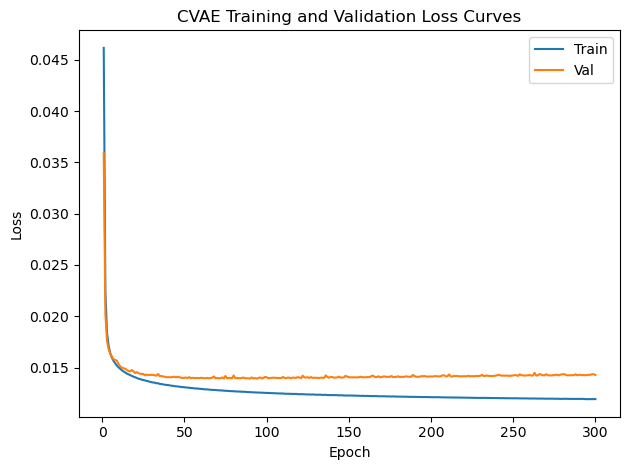

In [56]:
num_epochs = range(1, epochs + 1)

plt.plot(num_epochs, train_losses, label="Train")
plt.plot(num_epochs, val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CVAE Training and Validation Loss Curves")
plt.legend()

plt.tight_layout()
plt.show()

### 10. Generate Counterfactuals

In [57]:
test(test_loader, model, device)

Saved 64 original images to ../training-results/cvae/results/original/
Saved 64 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 1 completed. Total images processed: 64
Saved 64 original images to ../training-results/cvae/results/original/
Saved 64 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 2 completed. Total images processed: 128
Saved 64 original images to ../training-results/cvae/results/original/
Saved 64 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 3 completed. Total images processed: 192
Saved 64 original images to ../training-results/cvae/results/original/
Saved 64 counterfactual images and pairs to ../training-results/cvae/results/counterfactuals/
Batch 4 completed. Total images processed: 256
Saved 64 original images to ../training-results/cvae/results/original/
Saved 64 counterfactual images and pairs to ../training-results/cvae/results/count

### 10.1 Identify Original and Counterfactual Labels


In [8]:
import pandas as pd

LABEL_NAMES = {0: "healthy", 1: "pneumonia"}

def label_tensor_to_class_index(label):
    """Return class index from a scalar or one-hot label tensor."""
    label = torch.as_tensor(label).detach().cpu()
    if label.ndim == 0 or label.numel() == 1:
        return int(label.item())
    return int(torch.argmax(label).item())

def identify_counterfactual_labels(test_dataset, results_dir=project_root / "training-results" / "cvae" / "results"):
    """Map saved original/counterfactual images to labels from test_dataset.

    Original labels come directly from test_dataset. Counterfactual labels are the
    flipped target labels used in test(): healthy <-> pneumonia.
    """
    # if results_dir is None:
    #     results_dir = project_root / "training-results" / "cvae" / "results"

    results_dir = Path(results_dir)
    original_dir = results_dir / "original"
    counterfactual_dir = results_dir / "counterfactuals"

    rows = []
    for image_idx, label in enumerate(test_dataset.labels):
        original_class = label_tensor_to_class_index(label)
        counterfactual_class = 1 - original_class

        rows.append({
            "image_index": f"{image_idx:06d}",
            "original_image": str(original_dir / f"img_{image_idx:06d}_original.png"),
            "original_label_id": original_class,
            "original_label": LABEL_NAMES[original_class],
            "counterfactual_image": str(counterfactual_dir / f"img_{image_idx:06d}_counterfactual.png"),
            "counterfactual_label_id": counterfactual_class,
            "counterfactual_label": LABEL_NAMES[counterfactual_class],
        })

    labels_df = pd.DataFrame(rows)
    output_csv = results_dir / "counterfactual_labels.csv"
    labels_df.to_csv(output_csv, index=False)

    print(f"Saved labels for {len(labels_df)} original/counterfactual pairs to: {output_csv}")
    print("\nOriginal image label counts:")
    print(labels_df["original_label"].value_counts().to_string())
    print("\nCounterfactual image label counts:")
    print(labels_df["counterfactual_label"].value_counts().to_string())

    return labels_df

labels_df = identify_counterfactual_labels(test_dataset)

Saved labels for 9425 original/counterfactual pairs to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_labels.csv

Original image label counts:
original_label
healthy      9375
pneumonia      50

Counterfactual image label counts:
counterfactual_label
pneumonia    9375
healthy        50


In [ ]:
heatmap_paths = save_cvae_change_heatmap_sweep(test_dataset)

print(f"Saved {len(heatmap_paths)} heatmap files.")
print(f"First heatmap: {heatmap_paths[0]}")

### 11. Evaluate

In [3]:
DEFAULT_RESULTS_DIR = project_root / "training-results" / "cvae" / "results"

In [4]:
original_dir = DEFAULT_RESULTS_DIR / "original"
counterfactual_dir = DEFAULT_RESULTS_DIR / "counterfactuals"
output_json = DEFAULT_RESULTS_DIR / "counterfactual_metrics.json"
output_csv = DEFAULT_RESULTS_DIR / "counterfactual_ssim.csv"
batch_size = 32
num_workers = 0
device = "cuda" if torch.cuda.is_available() else "cpu"
allow_download = False

In [5]:
ssim_mean, ssim_std, ssim_min, ssim_max, ssim_rows = ssim_metric_calculation(device, output_csv, original_dir, counterfactual_dir)
fid, num_counterfactual_images, num_reference_images = fid_metric_calculation(original_dir, counterfactual_dir, device, batch_size, num_workers)

result = EvaluationResult(
    num_ssim_pairs=len(ssim_rows),
    ssim_mean=ssim_mean,
    ssim_std=ssim_std,
    ssim_min=ssim_min,
    ssim_max=ssim_max,
    num_counterfactual_images=num_counterfactual_images,
    num_reference_images=num_reference_images,
    fid=fid,
)
write_metrics_json(result, output_json)

print(json.dumps(asdict(result), indent=2))
print(f"\nSaved aggregate metrics to: {output_json}")
print(f"Saved per-image SSIM scores to: {output_csv}")

Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to C:\Users\gyren/.cache\torch\hub\checkpoints\weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 53.7MB/s]


{
  "num_ssim_pairs": 9425,
  "ssim_mean": 0.8190022797293625,
  "ssim_std": 0.05030662682659762,
  "ssim_min": 0.3929200768470764,
  "ssim_max": 0.9544135332107544,
  "num_counterfactual_images": 9425,
  "num_reference_images": 9425,
  "fid": 136.53575134277344
}

Saved aggregate metrics to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_metrics.json
Saved per-image SSIM scores to: E:\Gyovana\Computacao\Unicamp\IA376N\dgm-2026.1\projects\ecgpcx-ray\training-results\cvae\results\counterfactual_ssim.csv
